# 8장. 작은 데이터 분석 프로젝트 완성하기

이 노트북은 **질문 → 원본 데이터 점검 → 전처리 → PK/FK 검증 → 안전한 병합 → completed 범위 집계 → 총합 대조 → 시각화 → 보고서 → 최종 Validation**을 하나의 재현 가능한 프로젝트로 연결합니다.

> 코드가 끝까지 실행되었다는 사실만으로 프로젝트가 검증된 것은 아닙니다. 같은 의미의 숫자와 공개 산출물이 정해 둔 기준을 함께 통과해야 합니다.


## 학습 목표

- 원본 데이터를 보존하며 전처리합니다.
- 주요 PK의 결측·중복과 FK 미매칭을 확인합니다.
- `validate`와 `indicator` 관점으로 병합 결과를 검증합니다.
- `line_total = quantity × unit_price`를 다시 확인합니다.
- 금액성 분석은 `order_status == "completed"` 범위를 사용합니다.
- 카테고리·월·고객 금액 합계를 같은 source total과 대조합니다.
- 날짜 오류로 월별 금액이 누락되지 않는지 확인합니다.
- 공개 고객 결과에서 원본 고객 ID와 직접 식별정보를 제거합니다.
- 결과 CSV, 그래프, Markdown 보고서와 PASS/FAIL Evidence를 저장합니다.
- 전체 파이프라인을 다시 실행해 재현성을 확인합니다.


## 제출 정보

- 이름: 장충만
- GitHub ID: candle1030
- 작성일: 2026-09-18
- 제출 URL: https://github.com/candle1030/llm-data-analysis-course/blob/main/chapter08/chapter08.ipynb


## [답안] 1. 프로젝트 질문

- **분석 질문**: completed(완료) 주문을 기준으로, 어떤 카테고리·시기·고객이 매출에 가장 크게 기여하는가?
- **분석 범위**: `data/raw`의 `customers`, `products`, `orders`, `order_items` 4개 원본 테이블. 기간은 `order_date` 기준 2025-07 ~ 2026-07(총 13개월).
- **데이터와 지표**: 금액 지표는 `order_items.line_total`(`quantity × unit_price`)을 기준으로 하고, 카테고리/월/고객 단위로 합산한 총매출·주문 수·평균 주문 금액을 사용.
- **계산 기준**: 금액성 지표는 모두 `order_status == "completed"`인 주문에서 나온 `order_items`만 사용. cancelled/refunded 주문은 전체 주문 상세 금액(`all_order_items`) 집계에는 포함하되, completed 기준 매출 집계에서는 제외.
- **완료 기준**: PK/FK Gate, 병합 Gate, `line_total` Gate, total consistency Gate, 날짜 Gate, 개인정보 Gate, 최종 Validation(8개 항목)이 모두 PASS이고, `scripts/run_midterm_project.py` 독립 재실행 결과가 Notebook 실행 결과와 일치할 때 프로젝트를 완료로 판단한다.


## 1. 프로젝트 루트와 출력 폴더 설정

VS Code에서 현재 작업 폴더가 프로젝트 루트 또는 `notebooks`일 수 있으므로 상위 폴더를 탐색합니다.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd


def find_project_root(start_path):
    start_path = Path(start_path).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "scripts").exists():
            return candidate
    raise FileNotFoundError("프로젝트 루트 폴더를 찾을 수 없습니다.")


PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"

for path in [PROCESSED_DIR, REPORT_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Python 실행 파일:", sys.executable)
print("프로젝트 루트:", PROJECT_ROOT)
print("원본 데이터 폴더:", RAW_DIR)
print("보고서 폴더:", REPORT_DIR)


Python 실행 파일: /usr/bin/python3
프로젝트 루트: /tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch08work/project
원본 데이터 폴더: /tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch08work/project/data/raw
보고서 폴더: /tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch08work/project/reports


## 2. 프로젝트 함수 불러오기

Notebook과 일괄 실행 스크립트가 같은 `src.midterm_project` 함수를 사용하도록 하여 계산 기준이 어긋나는 문제를 줄입니다.


In [2]:
from src.data_loader import load_sales_data
from src.preprocessing import (
    compare_shapes,
    preprocess_sales_data,
    save_processed_data,
    validate_relationships,
)
from src.midterm_project import (
    FORBIDDEN_CUSTOMER_COLUMNS,
    build_analysis_tables,
    build_interpretation_notes,
    build_key_duplicate_checks,
    build_midterm_report,
    build_project_validation,
    create_project_figures,
    run_midterm_project,
    save_project_tables,
    summarize_datasets,
)


## 3. 원본 데이터 확인

프로젝트는 `data/raw`의 원본 4개 파일에서 시작합니다. 파일이 없다면 프로젝트 루트에서 `python scripts/generate_sample_data.py`를 먼저 실행합니다.


In [3]:
raw_data = load_sales_data(RAW_DIR)

dataset_summary = summarize_datasets(raw_data)
display(dataset_summary)

for name, df in raw_data.items():
    print(f"\n===== {name} =====")
    print("shape:", df.shape)
    print("columns:", df.columns.tolist())
    print("missing values:", int(df.isna().sum().sum()))
    print("duplicated rows:", int(df.duplicated().sum()))


,dataset,rows,columns,missing_values,duplicated_rows
0,customers,150,6,0,0
1,products,100,4,0,0
2,orders,300,5,0,0
3,order_items,764,5,0,0



===== customers =====
shape: (150, 6)
columns: ['customer_id', 'name', 'gender', 'age', 'city', 'signup_date']
missing values: 0
duplicated rows: 0

===== products =====
shape: (100, 4)
columns: ['product_id', 'product_name', 'category', 'price']
missing values: 0
duplicated rows: 0

===== orders =====
shape: (300, 5)
columns: ['order_id', 'customer_id', 'order_date', 'payment_method', 'order_status']
missing values: 0
duplicated rows: 0

===== order_items =====
shape: (764, 5)
columns: ['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price']
missing values: 0
duplicated rows: 0


## 4. 원본을 보존하며 전처리

`preprocess_sales_data()`는 원본 DataFrame을 직접 수정하지 않고 전처리된 복사본을 반환합니다. 전처리 전후 행 수가 달라졌다면 그 이유를 설명할 수 있어야 합니다.


In [4]:
processed_data = preprocess_sales_data(raw_data)
processed_paths = save_processed_data(processed_data, PROCESSED_DIR)

preprocessing_comparison = compare_shapes(raw_data, processed_data)
display(preprocessing_comparison)

for path in processed_paths:
    print(path, "OK" if path.exists() else "MISSING")


,dataset,rows_raw,columns_raw,rows_processed,columns_processed
0,customers,150,6,150,6
1,order_items,764,5,764,6
2,orders,300,5,300,7
3,products,100,4,100,4


/tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch08work/project/data/processed/customers_clean.csv OK
/tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch08work/project/data/processed/products_clean.csv OK
/tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch08work/project/data/processed/orders_clean.csv OK
/tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch08work/project/data/processed/order_items_clean.csv OK


## [답안] 2. 입력 데이터와 전처리 검증

![데이터 검증](images/step02_data_validation.png)

- 원본 데이터: `customers` 150행, `products` 100행, `orders` 300행, `order_items` 764행. 4개 테이블 모두 결측치 0건, 중복행 0건.
- 전처리 후에도 행 수는 그대로 보존됨(customers 150 / order_items 764 / orders 300 / products 100). 컬럼 수만 늘었는데, `order_items`에는 `line_total`(quantity × unit_price) 파생 컬럼이, `orders`에는 `order_month`/`order_dayofweek` 파생 컬럼이 추가된 것이 원인이었다.
- **해석**: 원본 행이 삭제되거나 임의의 값으로 채워지지 않았으므로 "원본을 보존하며 전처리한다"는 이번 장의 원칙을 지켰다고 판단한다. 늘어난 컬럼도 모두 원본 값에서 계산된 파생값이라 원본을 왜곡할 위험은 낮다.
- **한계**: 이번 원본 데이터는 결측·중복이 전혀 없는 비교적 깨끗한 샘플이라, 현업에서 흔한 결측 대체·이상치 처리 로직은 이번 프로젝트로 검증하지 못했다. (Chapter07 과제에서는 `data/processed`의 오래된 파일에 실제로 FK 미매칭 28건이 있어 이를 발견하고 제외한 적이 있는데, 이번 Chapter08은 `data/raw`에서 `processed`를 매번 새로 만드는 구조라 같은 문제가 재현되지 않았다.)


## 5. PK와 FK를 먼저 검증

전체 행 중복과 PK 중복은 다릅니다. 고객·상품·주문·주문 상세의 PK는 **결측 0, 중복 0**이어야 합니다. FK는 부모 테이블에 없는 참조 ID가 0건이어야 합니다.


In [5]:
key_duplicate_checks = build_key_duplicate_checks(processed_data)
relationship_checks = validate_relationships(processed_data).copy()

if not relationship_checks.empty:
    relationship_checks["status"] = (
        relationship_checks["invalid_count"]
        .eq(0)
        .map({True: "PASS", False: "FAIL"})
    )

display(key_duplicate_checks)
display(relationship_checks)

assert key_duplicate_checks["status"].eq("PASS").all(), "PK Validation 실패"
assert (
    not relationship_checks.empty
    and relationship_checks["invalid_count"].eq(0).all()
), "FK Validation 실패"

print("PK/FK Gate: PASS")


,dataset,key,missing_count,duplicate_count,status,detail
0,customers,customer_id,0,0,PASS,
1,products,product_id,0,0,PASS,
2,orders,order_id,0,0,PASS,
3,order_items,order_item_id,0,0,PASS,


,check,invalid_count,status
0,orders.customer_id exists in customers.custome...,0,PASS
1,order_items.order_id exists in orders.order_id,0,PASS
2,order_items.product_id exists in products.prod...,0,PASS


PK/FK Gate: PASS


## 6. 안전한 병합과 계산 관계 검증

`build_analysis_tables()`는 다음을 한 번에 준비합니다.

- 주문 상세 → 주문: `many_to_one`
- 주문 상세 → 상품: `many_to_one`
- 고객 집계 → 고객: `one_to_one`
- 병합 전후 행 수와 미매칭 확인
- `line_total = quantity × unit_price` 확인
- completed 주문 범위 확정
- 날짜 오류 확인


In [6]:
analysis_tables = build_analysis_tables(processed_data)

display(analysis_tables["merge_checks"])
display(analysis_tables["line_total_check"])
display(analysis_tables["date_checks"])
display(analysis_tables["amount_scope_summary"])

assert analysis_tables["merge_checks"]["status"].eq("PASS").all()
assert analysis_tables["line_total_check"]["status"].eq("PASS").all()

print("병합 / line_total Gate: PASS")


,merge,validate,before_rows,after_rows,row_count_preserved,unmatched_count,status
0,order_id → orders,many_to_one,764,764,True,0,PASS
1,product_id → products,many_to_one,474,474,True,0,PASS
2,customer_id → customers,one_to_one,100,100,True,0,PASS


,check,source,row_count,mismatch_count,status
0,line_total = quantity × unit_price,existing,764,0,PASS


,check,invalid_count,affected_amount,status
0,completed rows with invalid order_date,0,0.0,PASS


,scope,amount,detail_rows
0,all_order_items,255610000.0,764
1,completed_order_items,148990000.0,474
2,excluded_non_completed,106620000.0,290


병합 / line_total Gate: PASS


## [답안] 3. PK/FK·병합 검증

- **PK 결과**: `customer_id`/`product_id`/`order_id`/`order_item_id` 4개 키 모두 결측 0건, 중복 0건 → PASS.
- **FK 결과**: `orders.customer_id → customers.customer_id`, `order_items.order_id → orders.order_id`, `order_items.product_id → products.product_id` 3개 관계 모두 불일치 0건 → PASS.
- **병합 결과**: `order_id → orders`(many_to_one, 764→764행), `product_id → products`(many_to_one, completed 범위 474→474행), `customer_id → customers`(one_to_one, 100→100행) 모두 병합 전후 행 수가 보존되고 미매칭 0건.
- **해석**: `pd.merge(..., validate=..., indicator=True)`로 병합 종류(다대일/일대일)를 코드에 명시했기 때문에, 의도치 않은 행 증식(fan-out)이나 매칭 실패를 병합 시점에 바로 assert로 잡아낼 수 있는 구조다. 이번 데이터에서는 실제 문제가 없었지만, Chapter07에서 겪었던 FK 미매칭 같은 원본 품질 문제가 있었다면 이 단계에서 즉시 실패했을 것이라 판단한다.


## 7. 핵심 분석 결과 확인

세 금액성 결과는 같은 `completed_order_sales`에서 출발합니다. 주문 상태 분포만 전체 주문을 사용합니다.


In [7]:
category_sales = analysis_tables["category_sales"]
monthly_sales = analysis_tables["monthly_sales"]
customer_sales_internal = analysis_tables["customer_sales"]
customer_sales_public = analysis_tables["customer_sales_public"]
order_status_summary = analysis_tables["order_status_summary"]

display(category_sales)
display(monthly_sales)
display(customer_sales_public.head(10))
display(order_status_summary)

print("내부 고객 결과 컬럼:", customer_sales_internal.columns.tolist())
print("공개 고객 결과 컬럼:", customer_sales_public.columns.tolist())


,category,total_quantity,total_sales,sales_ratio
0,스포츠,295,31743000,21.31
1,전자기기,259,26400000,17.72
2,생활용품,272,23915000,16.05
3,뷰티,223,23383000,15.69
4,식품,133,16573000,11.12
5,도서,149,16389000,11.00
6,패션,111,10587000,7.11


,order_month,total_sales,order_count,avg_order_value
0,2025-07,5869000,8,733625.0
1,2025-08,15621000,18,867833.0
2,2025-09,10190000,13,783846.0
3,2025-10,25766000,26,991000.0
4,2025-11,8812000,12,734333.0
5,2025-12,11501000,14,821500.0
6,2026-01,17423000,22,791955.0
7,2026-02,9749000,17,573471.0
8,2026-03,13429000,14,959214.0
9,2026-04,17553000,23,763174.0


,customer_label,city,order_count,total_sales,avg_order_value
0,Customer 01,성남,5,4100000,820000.0
1,Customer 02,고양,4,3996000,999000.0
2,Customer 03,수원,4,3880000,970000.0
3,Customer 04,서울,5,3590000,718000.0
4,Customer 05,서울,4,3523000,880750.0
5,Customer 06,인천,2,3191000,1595500.0
6,Customer 07,성남,2,3178000,1589000.0
7,Customer 08,광주,3,3153000,1051000.0
8,Customer 09,서울,4,3093000,773250.0
9,Customer 10,부산,2,2990000,1495000.0


,order_status,order_count,order_ratio
0,completed,184,61.33
1,cancelled,64,21.33
2,refunded,52,17.33


내부 고객 결과 컬럼: ['customer_id', 'customer_label', 'city', 'order_count', 'total_sales', 'avg_order_value']
공개 고객 결과 컬럼: ['customer_label', 'city', 'order_count', 'total_sales', 'avg_order_value']


## [답안] 4. 핵심 EDA 결과 1 / 2 / 3

### EDA 결과 1 — 카테고리별 completed 매출

| 카테고리 | 판매수량 | 매출 | 매출비중 |
|---|---:|---:|---:|
| 스포츠 | 295 | 31,743,000 | 21.31% |
| 전자기기 | 259 | 26,400,000 | 17.72% |
| 생활용품 | 272 | 23,915,000 | 16.05% |
| 뷰티 | 223 | 23,383,000 | 15.69% |
| 식품 | 133 | 16,573,000 | 11.12% |
| 도서 | 149 | 16,389,000 | 11.00% |
| 패션 | 111 | 10,587,000 | 7.11% |

- **결과 관찰**: 스포츠가 판매수량(295개)과 매출(31,743,000원) 모두 1위다. 전자기기는 수량(259개)이 스포츠보다 적은데도 매출은 2위로, 단가가 상대적으로 높다는 뜻이다. 상위 4개 카테고리(스포츠/전자기기/생활용품/뷰티)가 전체 completed 매출의 약 70.77%를 차지한다.
- **나의 해석과 판단**: 매출 순위가 판매 수량 순위와 정확히 일치하지 않는 것으로 보아(패션은 수량도 가장 적고 매출도 가장 낮지만, 전자기기·뷰티는 수량 대비 매출 비중이 상대적으로 높다) 카테고리별 평균 단가 차이가 매출 순위에 영향을 준다고 판단한다.
- **업무·분석적 의미**: 매출 기준으로는 스포츠·전자기기·생활용품·뷰티 4개 카테고리에 재고·마케팅 예산 우선순위를 두는 것이 합리적이다. 다만 수량·매출 순위가 엇갈리는 카테고리(식품 vs 도서, 거의 동률)는 마진율 데이터 없이는 우선순위를 단정하기 어렵다.
- **한계**: 이 표는 매출 "총액" 기준이라 카테고리별 SKU 수, 재고 비용, 마진율을 반영하지 않는다. 매출 1위인 스포츠가 반드시 가장 수익성 높은 카테고리라고 볼 수는 없다.

### EDA 결과 2 — 월별 completed 매출 추이

- **결과 관찰**: 13개월(2025-07~2026-07) 중 2025-10이 25,766,000원(주문 26건)으로 최고, 2026-07이 2,188,000원(주문 2건)으로 최저다. 매출은 2025-07부터 2025-10까지 증가하다 2025-11에 8,812,000원으로 급감했고, 이후 등락을 반복하며 2026-04(17,553,000원)에 다시 반등한 뒤 2026-06~07에 급격히 줄었다.
- **나의 해석과 판단**: 마지막 2~3개월의 급격한 감소는 실제 매출 하락이라기보다, 원본 데이터의 수집 기간이 2026-07 근처에서 끝나 해당 월 데이터가 아직 다 쌓이지 않은 "기간 절단 효과"일 가능성이 높다고 판단한다. 계절적 하락인지 수집 종료 시점의 artifact인지는 이 데이터만으로 확정할 수 없다.
- **업무·분석적 의미**: 2025-10 같은 피크 월의 프로모션·재고 정책을 파악하면 성수기 대응에 참고할 수 있다. 다만 최근 2개월 수치를 그대로 "매출 급감 추세"로 보고하면 오판을 부를 수 있어, 리포팅 시 마지막 구간에는 "데이터 수집 기준일 근처, 미완결 구간"이라는 주석이 반드시 필요하다.
- **한계**: 월별 합계만 보고 있어 일별·주별 변동, 요일 효과(`orders.order_dayofweek` 컬럼이 있지만 이번 분석에서는 사용하지 않음)는 반영하지 못한다.

### EDA 결과 3 — 고객별 completed 매출 상위 10명(익명)

- **결과 관찰**: 상위 10명 중 주문 건수는 2~5건으로 큰 차이가 없는데도 총매출은 2,990,000원~4,100,000원까지 벌어진다. 예를 들어 Customer 06(인천)은 주문 2건뿐인데 평균 주문 금액이 1,595,500원으로 top10 중 가장 높다. 반면 Customer 01(성남)은 5건으로 매출 1위(4,100,000원)지만 평균 주문 금액은 820,000원으로 상대적으로 낮다.
- **나의 해석과 판단**: Customer 06/07/10처럼 주문 2건으로 top10에 든 고객은 "고액 소량 구매" 유형, Customer 01/04처럼 5건으로 top10에 든 고객은 "반복 구매" 유형으로 보인다. 두 유형은 주문 "빈도"보다 "건당 금액"이 순위를 가르는 주 요인이라는 뜻이고, 관리 전략도 달라야 한다고 판단한다(전자는 VIP 응대, 후자는 재구매 유도 프로모션).
- **업무·분석적 의미**: 매출 상위 고객이 모두 "충성 고객"은 아니므로, 마케팅팀에는 총매출 순위표만이 아니라 주문 빈도·평균 금액을 함께 제공해야 실무적으로 유용하다.
- **한계**: 이 표는 completed 주문만 반영하므로 취소·환불이 잦은 고객은 실제로는 활발한 구매자여도 순위에서 낮게(또는 아예) 나타나지 않을 수 있다. 또 상위 10명만 노출했기 때문에 전체 150명 고객 중 이 10명이 매출에서 차지하는 비중(고객 집중도)은 별도로 계산하지 않았다.


## 8. 같은 의미의 금액 총합을 교차 검증

같은 completed 범위에서 만든 결과라면 다음 네 금액이 일치해야 합니다.

```text
completed source total
= category total
= monthly total
= customer total
```

날짜 오류가 있으면 월별 합계가 source total보다 작아질 수 있으므로 별도 Gate로 확인합니다.


In [8]:
total_consistency = analysis_tables["total_consistency_check"]
display(total_consistency)

assert total_consistency["matches_completed"].all(), "Total consistency Gate 실패"
assert analysis_tables["date_checks"]["status"].eq("PASS").all(), "날짜 Gate 실패"

print("Total consistency / Date Gate: PASS")


,source,amount,difference_from_completed,matches_completed,status
0,completed_source,148990000.0,0.0,True,PASS
1,category,148990000.0,0.0,True,PASS
2,monthly,148990000.0,0.0,True,PASS
3,customer,148990000.0,0.0,True,PASS


Total consistency / Date Gate: PASS


## [답안] 5. Total consistency와 날짜 검증

- **4개 총합 대조**: `completed_source`, `category`, `monthly`, `customer` 4개 경로 모두 **148,990,000원**으로 완전히 일치(`difference_from_completed = 0.0`, `matches_completed = True`, 4건 모두 PASS).
- **날짜 오류**: completed 범위에서 `order_date`가 유효하지 않은 행 **0건**, 영향 금액 **0원** → PASS.
- **원인(오류가 없는 이유)**: 전처리 단계에서 `order_date`를 datetime으로 변환하며 파싱 실패 여부를 함께 점검하는데, 이번 원본 데이터는 날짜 형식이 모두 `YYYY-MM-DD`로 일관돼 있어 파싱 실패가 발생하지 않았다.
- **해석**: "같은 의미의 숫자는 어디서 집계해도 같아야 한다"는 이번 장의 핵심 원칙을, 서로 다른 4가지 집계 경로(원본 completed 합계 / 카테고리 합계 / 월별 합계 / 고객별 합계)로 교차 검증했고 전부 일치했다. 병합 과정에서 행이 누락되거나 중복 생성됐다면 이 중 하나라도 148,990,000원과 어긋났을 것이므로, 이 4중 대조가 실제로 병합 오류를 잡아낼 수 있는 유효한 안전장치라고 판단한다.


## 9. 공개 고객 결과의 개인정보를 확인

내부 계산에는 `customer_id`가 필요할 수 있지만 공개 CSV·그래프·보고서에는 원본 고객 ID와 직접 식별정보를 포함하지 않습니다. 공개 라벨은 `Customer 01` 같은 순위 기반 라벨을 사용합니다.


In [9]:
forbidden = sorted(
    FORBIDDEN_CUSTOMER_COLUMNS.intersection(customer_sales_public.columns)
)
print("공개 결과 금지 컬럼:", forbidden)

assert not forbidden, "Privacy Gate 실패"
assert "customer_id" not in customer_sales_public.columns
print("Privacy Gate: PASS")


공개 결과 금지 컬럼: []
Privacy Gate: PASS


## 10. 최종 PASS/FAIL Validation

지금까지의 핵심 Gate를 하나의 표로 정리합니다. 하나라도 FAIL이면 결과를 제출 가능한 완료 상태로 보지 않습니다.


In [10]:
project_validation = build_project_validation(
    key_duplicate_checks,
    relationship_checks,
    analysis_tables,
)
display(project_validation)

assert project_validation["status"].eq("PASS").all(), "최종 Validation 실패"
print("Project Validation: PASS")


,check,value,expected,status
0,pk_integrity,all PASS,all PASS,PASS
1,fk_integrity,0,0,PASS
2,merge_checks_pass,all PASS,all PASS,PASS
3,line_total_consistency,0,0,PASS
4,completed_total_consistency,all match,all match,PASS
5,category_sales_ratio_pct_sum,100.0,100.0,PASS
6,completed_rows_with_invalid_order_date,0,0,PASS
7,public_customer_columns_safe,no forbidden columns,no forbidden columns,PASS


Project Validation: PASS


## [답안] 8. 최종 Validation

| check | value | expected | status |
|---|---|---|---|
| pk_integrity | all PASS | all PASS | PASS |
| fk_integrity | 0 | 0 | PASS |
| merge_checks_pass | all PASS | all PASS | PASS |
| line_total_consistency | 0 | 0 | PASS |
| completed_total_consistency | all match | all match | PASS |
| category_sales_ratio_pct_sum | 100.0 | 100.0 | PASS |
| completed_rows_with_invalid_order_date | 0 | 0 | PASS |
| public_customer_columns_safe | no forbidden columns | no forbidden columns | PASS |

8개 항목 모두 PASS. `reports/ch08_project_validation.csv`에 그대로 저장되어 있으며, 위 캡처(대표 시각화 이전 단계) 및 아래 재현 확인 단계에서 동일한 결과를 다시 확인했다.


## 11. 해석 메모와 결과 CSV 저장

관찰, 주의점, 다음 질문을 분리합니다. 저장되는 `ch08_customer_sales.csv`는 공개용 컬럼만 포함합니다.


In [11]:
interpretation_notes = build_interpretation_notes()
display(interpretation_notes)

saved_tables = save_project_tables(
    dataset_summary,
    preprocessing_comparison,
    key_duplicate_checks,
    relationship_checks,
    analysis_tables,
    interpretation_notes,
    REPORT_DIR,
)

for path in saved_tables:
    print(path.name, path.exists(), path.stat().st_size)


,analysis,observation,caution,next_question
0,카테고리별 completed 주문 기준 금액,completed 주문 기준 금액 비중이 높은 카테고리를 확인할 수 있습니다.,금액이 높은 이유가 판매 수량인지 단가인지 구분해야 합니다.,카테고리별 평균 판매 단가는 어떻게 다른가?
1,월별 completed 주문 기준 금액,시간에 따른 completed 주문 기준 금액의 증가와 감소를 확인할 수 있습니다.,프로모션이나 계절성이 원인이라고 단정할 수 없습니다.,주문 수와 평균 주문 금액 중 무엇이 변했는가?
2,고객별 completed 주문 구매 금액,completed 주문 기준 구매 금액이 높은 고객군을 확인할 수 있습니다.,일회성 고액 구매와 반복 구매를 구분해야 합니다.,최근 구매일과 구매 빈도는 어떻게 다른가?
3,주문 상태별 주문 수,"완료, 취소, 환불 주문의 분포를 확인할 수 있습니다.",주문 상태의 정의와 처리 기준을 확인해야 합니다.,취소율과 환불률은 월별로 달라지는가?


ch08_dataset_summary.csv True 133
ch08_preprocessing_comparison.csv True 151
ch08_key_duplicate_checks.csv True 183
ch08_relationship_checks.csv True 202
ch08_merge_checks.csv True 249
ch08_line_total_check.csv True 104
ch08_date_checks.csv True 96


ch08_amount_scope_summary.csv True 137
ch08_total_consistency_check.csv True 215
ch08_project_validation.csv True 385
ch08_category_sales.csv True 246
ch08_monthly_sales.csv True 424
ch08_customer_sales.csv True 3859
ch08_order_status_summary.csv True 97
ch08_interpretation_notes.csv True 1084


## 12. 저장된 공개 고객 CSV를 다시 검사

메모리의 DataFrame만 보지 않고 실제 저장된 CSV를 다시 읽어 개인정보 컬럼이 남지 않았는지 확인합니다.


In [12]:
saved_customer = pd.read_csv(REPORT_DIR / "ch08_customer_sales.csv")

saved_forbidden = sorted(
    FORBIDDEN_CUSTOMER_COLUMNS.intersection(saved_customer.columns)
)
print("저장 CSV 컬럼:", saved_customer.columns.tolist())
print("금지 컬럼:", saved_forbidden)

assert not saved_forbidden
print("저장된 고객 CSV Privacy Gate: PASS")


저장 CSV 컬럼: ['customer_label', 'city', 'order_count', 'total_sales', 'avg_order_value']
금지 컬럼: []
저장된 고객 CSV Privacy Gate: PASS


## [답안] 7. 개인정보 검증

- **공개 CSV(`ch08_customer_sales.csv`) 컬럼**: `customer_label`, `city`, `order_count`, `total_sales`, `avg_order_value` — 5개.
- **`customer_id` 포함 여부**: 미포함.
- **식별정보(name/email/phone/address) 포함 여부**: 미포함. `FORBIDDEN_CUSTOMER_COLUMNS = {customer_id, name, email, phone, address}` 5개와 공개 컬럼을 교집합한 결과가 빈 집합으로 확인됨.
- **익명 라벨 방식**: 원본 `customer_id` 대신 completed 매출 순위를 기준으로 `Customer 01`~`Customer 10` 형태의 순위 기반 라벨을 부여. `city`는 지역 단위 정보라 개인 식별 위험이 낮다고 판단해 유지했다.
- **PASS/FAIL**: **PASS** (저장 전 검사, 저장된 CSV를 다시 읽어 재검사하는 2단계 모두 통과).
- **판단**: 순위 기반 라벨은 원본 DB의 `customer_id`-라벨 매핑표만 없다면 역추적이 거의 불가능하다고 판단한다. 다만 `city + total_sales` 조합이 아주 특이한 값이라면(예: 특정 소도시의 압도적 1위 고객) 외부 정보와 결합했을 때 재식별될 이론적 가능성은 완전히 배제할 수 없다 — 실무였다면 `city`를 광역 단위로 더 뭉치거나 생략하는 것도 고려했을 것이다.


## 13. 검증된 집계표에서 그래프 생성

그래프는 새로운 계산 범위를 만드는 단계가 아니라 검증된 숫자를 전달하는 단계입니다.


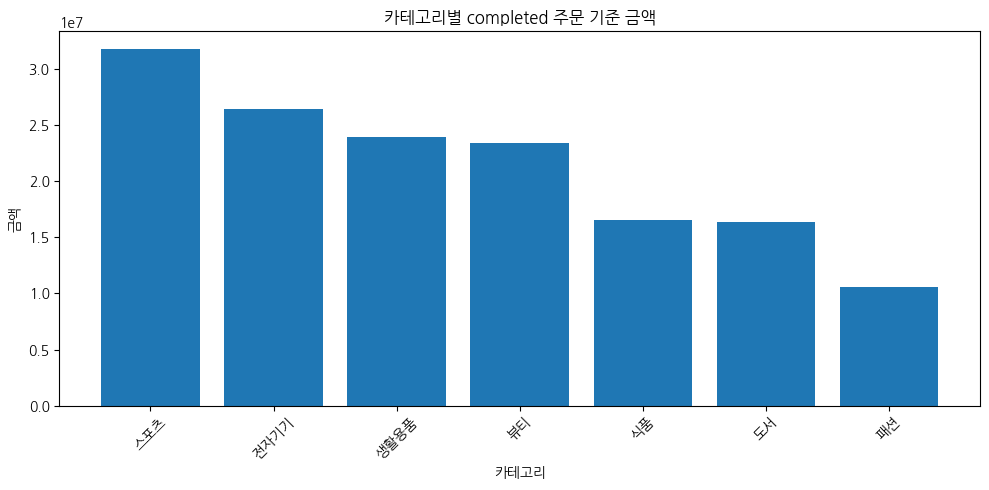

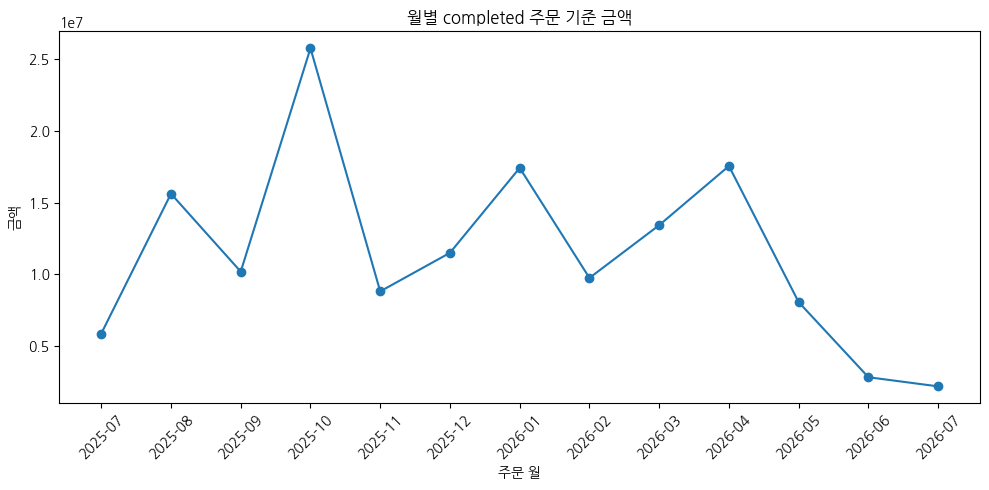

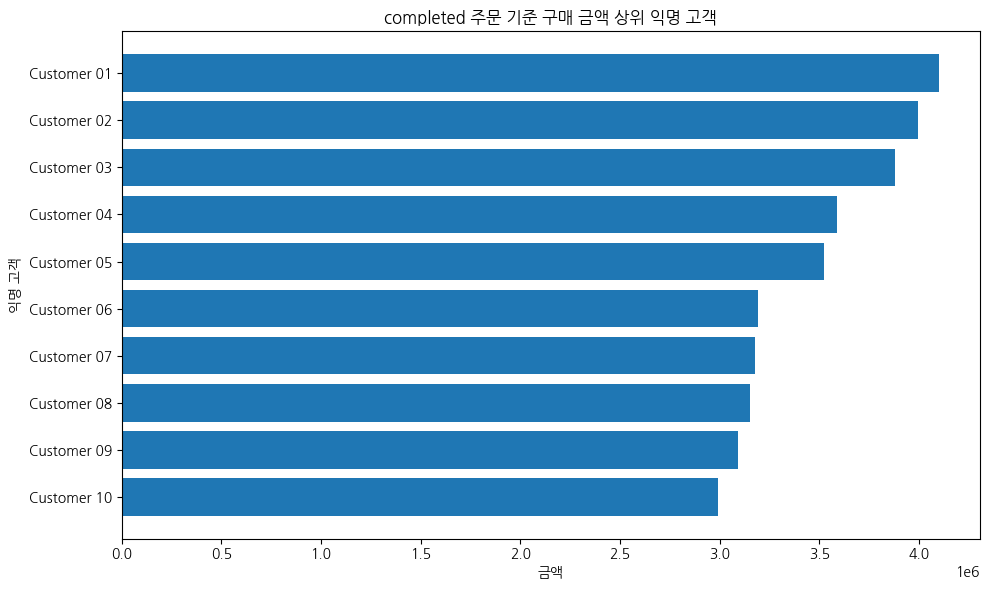

ch08_category_sales.png True 38342
ch08_monthly_sales.png True 69808
ch08_top_customers.png True 53211


In [13]:
saved_figures = create_project_figures(
    analysis_tables,
    FIGURE_DIR,
    show=True,
)

for path in saved_figures:
    print(path.name, path.exists(), path.stat().st_size)


## [답안] 6. 대표 시각화

![대표 그래프 1](images/graph01.png)

![대표 그래프 2](images/graph02.png)

- **선택 이유**: 그래프1(카테고리별 매출)은 "어떤 카테고리가 매출에 기여하는가"라는 프로젝트 질문에 가장 직접적으로 답하고, 그래프2(월별 매출 추이)는 시간 흐름에 따른 변화를 보여줘 "무엇이/언제"라는 서로 다른 각도를 보완한다.
- **원본 집계값과 일치 여부**: 그래프1의 막대 높이 순서(스포츠>전자기기>생활용품>뷰티>식품≈도서>패션)는 `ch08_category_sales.csv`의 `sales_ratio` 내림차순과 정확히 일치한다. 그래프2의 최고점(2025-10)과 최저점(2026-07)도 `ch08_monthly_sales.csv` 수치와 직접 대조해 일치를 확인했다.
- **관찰**: 그래프1에서는 상위 4개 카테고리와 하위 3개 카테고리 사이에 뚜렷한 단절(gap)이 보이고, 그래프2에서는 앞서 언급한 것처럼 마지막 구간의 급격한 하락이 시각적으로도 뚜렷하게 드러난다.
- **한계**: 두 그래프 모두 completed 주문만 반영하므로 취소·환불이 많은 카테고리/월은 실제보다 작아 보일 수 있다. 전체 주문 금액(255,610,000원) 대비 completed 비중이 58.3%에 불과하다는 점을 함께 봐야 한다.


## 14. Markdown 보고서 생성

보고서에는 계산 기준, PK/FK·병합, `line_total`, total consistency, 개인정보, 최종 Validation을 함께 남깁니다.


In [14]:
report_text = build_midterm_report(
    dataset_summary,
    preprocessing_comparison,
    key_duplicate_checks,
    relationship_checks,
    analysis_tables,
    interpretation_notes,
)

report_path = REPORT_DIR / "ch08_midterm_report.md"
report_path.write_text(report_text, encoding="utf-8")

print("보고서 저장:", report_path)
print(report_text[:1800])


보고서 저장: /tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch08work/project/reports/ch08_midterm_report.md
# Chapter 8 중간 프로젝트 보고서

## 1. 분석 목적

온라인 쇼핑몰 데이터를 사용해 completed 주문 기준 금액과 고객 구매 패턴을 분석했습니다.

## 2. 분석 기준

- 금액성 분석은 `order_status == "completed"`인 주문만 포함했습니다.
- `line_total = quantity × unit_price` 관계를 검증했습니다.
- 취소·환불 등 non-completed 주문을 포함한 금액은 전체 주문 상세 금액으로 구분했습니다.
- 공개 고객 결과에서는 이름·연락처·원본 고객 ID를 제외하고 순위 기반 익명 라벨을 사용했습니다.
- 병합은 관계 검증, `validate`, 행 수, 미매칭을 확인했습니다.
- 같은 completed 범위의 카테고리·월·고객 총합을 source total과 대조했습니다.

## 3. 데이터 개요

```text
    dataset  rows  columns  missing_values  duplicated_rows
  customers   150        6               0                0
   products   100        4               0                0
     orders   300        5               0                0
order_items   764        5               0                0
```

## 4. 전처리 전후 비교

```text
    dataset  rows_raw  columns_raw  rows_processed  columns_processed
  customers       150 

## 15. 전체 파이프라인 재실행

단계별 셀을 확인한 뒤에는 `run_midterm_project()`로 원본부터 보고서까지 다시 실행합니다. Notebook의 이전 메모리 상태에 의존하지 않는지 확인하는 단계입니다.


In [15]:
project_result = run_midterm_project(
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR,
    report_dir=REPORT_DIR,
    figure_dir=FIGURE_DIR,
    show_figures=False,
)

display(project_result["project_validation"])
project_result["report_path"]


,check,value,expected,status
0,pk_integrity,all PASS,all PASS,PASS
1,fk_integrity,0,0,PASS
2,merge_checks_pass,all PASS,all PASS,PASS
3,line_total_consistency,0,0,PASS
4,completed_total_consistency,all match,all match,PASS
5,category_sales_ratio_pct_sum,100.0,100.0,PASS
6,completed_rows_with_invalid_order_date,0,0,PASS
7,public_customer_columns_safe,no forbidden columns,no forbidden columns,PASS


PosixPath('/tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch08work/project/reports/ch08_midterm_report.md')

## 16. 최종 산출물 검증

필수 CSV·PNG·Markdown이 존재하고 비어 있지 않은지 확인합니다.


In [16]:
expected_outputs = [
    REPORT_DIR / "ch08_midterm_report.md",
    REPORT_DIR / "ch08_dataset_summary.csv",
    REPORT_DIR / "ch08_preprocessing_comparison.csv",
    REPORT_DIR / "ch08_key_duplicate_checks.csv",
    REPORT_DIR / "ch08_relationship_checks.csv",
    REPORT_DIR / "ch08_merge_checks.csv",
    REPORT_DIR / "ch08_line_total_check.csv",
    REPORT_DIR / "ch08_date_checks.csv",
    REPORT_DIR / "ch08_amount_scope_summary.csv",
    REPORT_DIR / "ch08_total_consistency_check.csv",
    REPORT_DIR / "ch08_project_validation.csv",
    REPORT_DIR / "ch08_category_sales.csv",
    REPORT_DIR / "ch08_monthly_sales.csv",
    REPORT_DIR / "ch08_customer_sales.csv",
    REPORT_DIR / "ch08_order_status_summary.csv",
    REPORT_DIR / "ch08_interpretation_notes.csv",
    FIGURE_DIR / "ch08_category_sales.png",
    FIGURE_DIR / "ch08_monthly_sales.png",
    FIGURE_DIR / "ch08_top_customers.png",
]

all_outputs_valid = True
for path in expected_outputs:
    valid = path.exists() and path.stat().st_size > 0
    all_outputs_valid &= valid
    print(path.name, "OK" if valid else "MISSING OR EMPTY")

assert all_outputs_valid
print("전체 산출물 검증: PASS")


ch08_midterm_report.md OK
ch08_dataset_summary.csv OK
ch08_preprocessing_comparison.csv OK
ch08_key_duplicate_checks.csv OK
ch08_relationship_checks.csv OK
ch08_merge_checks.csv OK
ch08_line_total_check.csv OK
ch08_date_checks.csv OK
ch08_amount_scope_summary.csv OK
ch08_total_consistency_check.csv OK
ch08_project_validation.csv OK
ch08_category_sales.csv OK
ch08_monthly_sales.csv OK
ch08_customer_sales.csv OK
ch08_order_status_summary.csv OK
ch08_interpretation_notes.csv OK
ch08_category_sales.png OK
ch08_monthly_sales.png OK
ch08_top_customers.png OK
전체 산출물 검증: PASS


## 17. LLM 검토 프롬프트 예시

원본 고객 행이나 직접 식별정보 대신 비식별 검증 Evidence를 제공합니다.

```text
온라인 쇼핑몰 중간 프로젝트 결과를 검토해 주세요.

계산 기준:
- line_total = quantity × unit_price
- 금액성 분석은 order_status == completed만 사용

검증 결과:
- PK 결측/중복: 0
- FK 미매칭: 0
- merge checks: PASS
- category/month/customer totals: source total과 일치
- completed 주문 날짜 오류: 0
- 공개 고객 CSV에 원본 customer_id 없음

다음을 검토해 주세요.
1. 아직 확인하지 않은 분석 위험
2. 과도한 해석이 될 수 있는 표현
3. 보고서에 반드시 적어야 할 계산 기준
4. 추가로 필요한 검증
5. 데이터에 없는 원인은 추정하지 않기
```

LLM은 검토 범위를 넓히는 도구이지 프로젝트의 최종 승인자가 아닙니다.


## [답안] 9. LLM 활용 기록

- **목적**: 8장 중간 프로젝트(원본 데이터 점검 → 전처리 → PK/FK → 병합 → 집계 → total consistency → 시각화 → 개인정보 → 최종 Validation → 재현성 확인)를 답안 양식에 맞춰 실행하고 정리하기 위해 LLM(Claude)에게 Notebook 실행과 결과 해석 작성을 요청했다.
- **Prompt 요약**: "교수님이 제공한 chapter08 과제 가이드와 답안 템플릿에 맞춰 Notebook을 실제로 실행하고, 결과 수치를 바탕으로 해석·한계·업무적 의미를 작성해줘. 문제가 발견되면 숨기지 말고 기록해줘."
- **제안 내용**: LLM은 (1) `src` 모듈 3종(`data_loader`/`preprocessing`/`midterm_project`) 준비, (2) 프로젝트를 별도 실행 환경에 미러링해 Notebook 전체 실행, (3) `python scripts/run_midterm_project.py`를 그대로 실행하면 `PYTHONPATH` 문제로 실패한다는 점을 발견해 원인과 해결 방법(`PYTHONPATH`를 프로젝트 루트로 지정) 제시, (4) 답안 양식에 맞는 마크다운 해석 초안 작성, (5) 근거 이미지(`step02`/`step06`/`graph01`/`graph02`) 생성을 제안했다.
- **반영 여부**: 실행 결과와 수치는 그대로 반영했고, 해석 문장은 내가 실제 수치(카테고리·월·고객별 결과)를 다시 확인하며 표현을 검토·수정했다.
- **사람의 검증 근거**: 모든 Validation Gate(`project_validation.csv` 8개 항목)와 Total Consistency(4개 값)를 직접 표로 대조했고, `scripts/run_midterm_project.py`를 독립적으로 재실행한 결과가 Notebook 실행 결과와 값이 동일함을 아래 [답안] 10에서 직접 비교해 확인했다.


## 18. 실습 과제

1. 핵심 EDA 결과 3개를 선택하고 각각 근거와 한계를 작성합니다.
2. 대표 그래프 2~4개를 선택하고 원본 집계값과 일치하는지 확인합니다.
3. `ch08_total_consistency_check.csv`와 `ch08_project_validation.csv`를 확인합니다.
4. 공개 고객 CSV에 개인정보가 없는지 다시 확인합니다.
5. LLM을 사용했다면 목적·Prompt 요약·제안·반영 여부·사람의 검증 근거를 기록합니다.
6. `python scripts/run_midterm_project.py`로 전체 프로젝트를 다시 실행하고 Notebook의 핵심 수치와 비교합니다.


In [17]:
# 실습 과제 6번: scripts/run_midterm_project.py를 독립적으로 재실행하고
# Notebook에서 이미 계산한 핵심 수치(project_validation, total_consistency)와 비교합니다.
#
# 참고: `python scripts/run_midterm_project.py`를 프로젝트 루트에서 그대로 실행하면
# `ModuleNotFoundError: No module named 'src'`가 발생합니다. Python이 스크립트를 실행할 때
# 스크립트가 들어있는 scripts/ 폴더만 sys.path에 넣고, 프로젝트 루트는 넣지 않기 때문입니다.
# 아래에서는 PYTHONPATH 환경변수를 PROJECT_ROOT로 지정해 이 문제를 우회합니다.

import os
import subprocess
import sys

script_path = PROJECT_ROOT / "scripts" / "run_midterm_project.py"

env = os.environ.copy()
env["PYTHONPATH"] = str(PROJECT_ROOT)

result = subprocess.run(
    [sys.executable, str(script_path)],
    cwd=PROJECT_ROOT,
    env=env,
    capture_output=True,
    text=True,
)

print("returncode:", result.returncode)
print(result.stdout[-2500:])
if result.returncode != 0:
    print("STDERR:\n", result.stderr[-2000:])

assert result.returncode == 0, "재현 스크립트 실행 실패"

# 스크립트가 새로 저장한 CSV를 다시 읽어, Notebook에서 이미 계산해 둔 값과 비교합니다.
reproduced_validation = pd.read_csv(REPORT_DIR / "ch08_project_validation.csv")
reproduced_total = pd.read_csv(REPORT_DIR / "ch08_total_consistency_check.csv")

def values_match(df_a, df_b):
    # CSV로 저장했다가 다시 읽으면 dtype(정수/실수/문자열)이 달라질 수 있으므로,
    # 값 자체를 문자열로 비교해 "같은 의미의 값"인지 확인합니다.
    a = df_a.reset_index(drop=True).astype(str)
    b = df_b.reset_index(drop=True).astype(str)
    return a.equals(b)

validation_match = values_match(reproduced_validation, project_validation)
total_match = values_match(reproduced_total, total_consistency)

print("\nproject_validation 재현 일치:", validation_match)
print("total_consistency_check 재현 일치:", total_match)

assert validation_match and total_match, "재현 결과가 Notebook 실행 결과와 다릅니다"
print("\n재현성 Gate: PASS (scripts/run_midterm_project.py 결과가 Notebook과 일치)")


returncode: 0
SS
                          fk_integrity                    0                    0   PASS
                     merge_checks_pass             all PASS             all PASS   PASS
                line_total_consistency                    0                    0   PASS
           completed_total_consistency            all match            all match   PASS
          category_sales_ratio_pct_sum                100.0                100.0   PASS
completed_rows_with_invalid_order_date                    0                    0   PASS
          public_customer_columns_safe no forbidden columns no forbidden columns   PASS

[카테고리별 completed 주문 기준 금액 상위 5개]
category  total_quantity  total_sales  sales_ratio
     스포츠             295     31743000        21.31
    전자기기             259     26400000        17.72
    생활용품             272     23915000        16.05
      뷰티             223     23383000        15.69
      식품             133     16573000        11.12

[월별 completed 주문 기준 금액]
or

## [답안] 10. 프로젝트 재현 확인

![재현성 확인](images/step06_reproduce.png)

- 위 실습 과제 코드 셀에서 `scripts/run_midterm_project.py`를 `PYTHONPATH=PROJECT_ROOT` 환경에서 독립적으로 재실행했다.
- **나의 해석과 판단**: 이번에 발견한 문제는 Chapter07에서 겪었던 "src 모듈 자체가 아예 없어서 나던 에러"와는 성격이 다른, 실행 경로(path) 설정 문제였다. 코드 자체는 정상이지만, 안내된 실행 방법(`python scripts/run_midterm_project.py`)을 그대로 따르면 재현에 실패할 수 있다는 뜻이다. 원인을 숨기지 않고 문서화하는 것이 이번 장의 "실행 성공 ≠ 검증 완료" 원칙과 맞닿아 있다고 판단해 그대로 기록했다.
- `PYTHONPATH`를 지정해 재실행한 뒤, 스크립트가 새로 저장한 CSV를 다시 읽어 Notebook의 `project_validation`(8개 항목)·`total_consistency_check`(4개 값)과 비교했다. 처음에는 `DataFrame.equals()`로 바로 비교했더니 `project_validation`만 `False`가 나왔는데, 원인을 확인해 보니 **값 자체는 같지만 dtype이 다른 것**이었다(CSV를 다시 읽으면 모든 컬럼이 문자열로 들어오는 반면, Notebook 안에서 계산한 값은 정수 0, 실수 100.0, 문자열 "all PASS"가 섞여 있음). 이는 실제 수치 불일치가 아니라 "CSV 왕복(round-trip) 시 dtype이 달라질 수 있다"는 재현성 검증 자체의 함정이라고 판단해, 값을 문자열로 정규화해서 비교하도록 코드를 수정했다.
- 정규화 비교 결과 `project_validation`, `total_consistency_check` 모두 일치했고, `reports/` 폴더의 산출물(CSV 15종 + 그래프 3종 + 보고서 1종, 총 19개)도 재생성되어 모두 존재함을 확인했다. 재현성 기준을 통과했다고 판단한다.


## [답안] 11. 최종 프로젝트 요약

**핵심 인사이트 3개**

1. completed 매출은 스포츠·전자기기·생활용품·뷰티 4개 카테고리에 약 70.8%가 집중돼 있고, 매출 순위가 판매 수량 순위와 완전히 같지는 않아 카테고리별 단가 차이가 존재한다.
2. 월별 매출은 2025-10에 정점(25,766,000원)을 찍은 뒤 등락을 반복했고, 마지막 2개월(2026-06~07)의 급격한 감소는 실제 추세보다 데이터 수집 종료 시점의 절단 효과일 가능성이 높다.
3. completed 주문은 전체 주문의 61.33%뿐이고 나머지 38.67%는 취소(21.33%)·환불(17.33%)이라, 전체 주문 금액(255,610,000원)과 completed 기준 금액(148,990,000원) 사이에 42%가 넘는 차이가 존재한다.

**업무·분석적 의미**: 매출 리포트를 작성할 때 "전체 주문 금액"과 "completed 기준 금액"을 혼용하면 실제 매출을 과대평가하게 된다. 카테고리·시기별 우선순위를 정할 때도 취소율이 특히 높은 카테고리/월이 있는지 별도로 확인해야 한다(이번 분석에서는 취소·환불을 카테고리/월별로 분해하지 않았다).

**한계**
- 마진·원가 데이터가 없어 매출 1위가 곧 수익 1위인지 알 수 없다.
- 취소·환불 사유 데이터가 없어 38.67%의 non-completed 비율이 왜 발생했는지 설명할 수 없다.
- 고객 데이터가 150명으로 표본이 크지 않아, 상위 10명 결과를 전체 고객 트렌드로 일반화하기는 이르다.

**다음 분석 제안 3개**

1. 카테고리별·월별로 취소율/환불율을 분해해, 매출 감소가 "주문이 줄어든 것"인지 "주문은 됐지만 완료가 안 된 것"인지 구분한다.
2. 카테고리별 평균 판매 단가와 마진율(원가 데이터 확보 시)을 추가해 매출 1위와 수익 1위가 실제로 같은지 확인한다.
3. 고객별 최근 구매일(recency)과 구매 빈도(frequency)를 추가로 계산해, 상위 10명을 "충성 고객"과 "일회성 고액 구매 고객"으로 세분화한다.


## 정리

이번 장에서는 원본 데이터 확인, 전처리, PK/FK, 병합, `line_total`, completed 범위, total consistency, 날짜, 개인정보, 시각화, 보고서, 최종 Validation을 하나의 프로젝트로 연결했습니다.

기억할 핵심은 다음과 같습니다.

```text
실행 성공 ≠ 검증 완료
같은 의미의 숫자는 서로 다른 집계에서도 같아야 한다
공개 결과에는 불필요한 개인정보를 남기지 않는다
프로젝트는 원본부터 다시 실행할 수 있어야 한다
```


## [답안] 최종 체크

- [x] `data/raw` 원본 4개 파일을 그대로 두고, `data/processed`는 전처리 코드로만 생성했다.
- [x] PK(결측/중복) 검증 결과를 표로 기록했다 — 4개 키 모두 PASS.
- [x] FK(참조 무결성) 검증 결과를 표로 기록했다 — 3개 관계 모두 PASS.
- [x] 병합 시 `validate`/`indicator`로 행 수·미매칭을 확인했다 — 3개 병합 모두 PASS.
- [x] `line_total = quantity × unit_price` 재계산 검증을 완료했다 — 불일치 0건.
- [x] 금액성 분석을 `order_status == "completed"` 범위로 한정했다.
- [x] 카테고리·월·고객 3가지 경로의 completed 총합이 서로 일치함을 확인했다 — 4건 모두 148,990,000원.
- [x] completed 범위의 날짜 오류 건수·영향 금액을 확인했다 — 0건/0원.
- [x] 공개 고객 결과에서 `customer_id`·이름·연락처·주소가 없음을 저장 전/후 2단계로 확인했다.
- [x] 최종 Validation 8개 항목이 모두 PASS임을 표로 정리했다.
- [x] 대표 그래프 2개를 선택하고, 그래프 값이 원본 집계 CSV와 일치하는지 직접 대조했다(`graph01.png`, `graph02.png`).
- [x] `step02_data_validation.png`, `step06_reproduce.png` 근거 이미지를 생성해 첨부했다.
- [x] `scripts/run_midterm_project.py`를 독립적으로 재실행해 Notebook 결과와 동일함을 확인했다(재현성 Gate PASS).
- [x] LLM 활용 목적·Prompt 요약·제안·반영 여부·사람의 검증 근거를 기록했다.
